
# Task 6 — Actor-Critic Experiments

本 Notebook 只负责实验，不重复实现算法源码。

基于 `src/` 中现有实现：

- `ActorCriticAgent`：1-step Actor-Critic
- `NStepActorCriticAgent`：5-step Actor-Critic
- `GAEActorCriticAgent`：Actor-Critic + GAE

流程：

1. 重新训练三个实验；
2. 保存每个实验的 `best` / `final` checkpoint；
3. 保存训练结果；
4. 绘制统一对比曲线；
5. 输出最终性能统计。

> 运行前建议 Restart Kernel，然后 Run All。


In [1]:

%load_ext autoreload
%autoreload 2

import sys
import json
import random
from pathlib import Path
from collections import deque

import gymnasium as gym
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()

if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError(
        "无法定位 task-06 项目根目录：请从 task-06/ 或 task-06/notebooks/ 运行本 Notebook。"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.actor_critic import ActorCriticAgent
from src.n_step_actor_critic import NStepActorCriticAgent
from src.gae_actor_critic import GAEActorCriticAgent

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
FIGURE_DIR = PROJECT_ROOT / "figures"
RESULT_DIR = PROJECT_ROOT / "results"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("RESULT_DIR:", RESULT_DIR)


PROJECT_ROOT: /workspace/YiFan/llm_agent/repos/RL-beginner/task-06-actor-critic
CHECKPOINT_DIR: /workspace/YiFan/llm_agent/repos/RL-beginner/task-06-actor-critic/checkpoints
FIGURE_DIR: /workspace/YiFan/llm_agent/repos/RL-beginner/task-06-actor-critic/figures
RESULT_DIR: /workspace/YiFan/llm_agent/repos/RL-beginner/task-06-actor-critic/results


## 1. 统一实验配置

In [2]:

SEED = 42

ENV_NAME = "CartPole-v1"
NUM_EPISODES = 500

HIDDEN_DIM = 128

ACTOR_LR = 1e-4
CRITIC_LR = 5e-4

GAMMA = 0.99

N_STEPS = 5
GAE_LAMBDA = 0.95

MOVING_AVG_WINDOW = 50
SUCCESS_THRESHOLD = 400

CONFIG = {
    "seed": SEED,
    "env_name": ENV_NAME,
    "num_episodes": NUM_EPISODES,
    "hidden_dim": HIDDEN_DIM,
    "actor_lr": ACTOR_LR,
    "critic_lr": CRITIC_LR,
    "gamma": GAMMA,
    "n_steps": N_STEPS,
    "gae_lambda": GAE_LAMBDA,
    "moving_avg_window": MOVING_AVG_WINDOW,
    "success_threshold": SUCCESS_THRESHOLD,
}

print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "env_name": "CartPole-v1",
  "num_episodes": 500,
  "hidden_dim": 128,
  "actor_lr": 0.0001,
  "critic_lr": 0.0005,
  "gamma": 0.99,
  "n_steps": 5,
  "gae_lambda": 0.95,
  "moving_avg_window": 50,
  "success_threshold": 400
}


## 2. 公共工具：随机种子、Moving Average、Checkpoint

In [3]:

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def moving_average(data, window=50):
    data = np.asarray(data, dtype=np.float32)

    if len(data) < window:
        return np.asarray([], dtype=np.float32)

    return np.convolve(
        data,
        np.ones(window, dtype=np.float32) / window,
        mode="valid",
    )


def first_reach_threshold(returns, threshold=400, window=50):
    ma = moving_average(returns, window=window)

    if len(ma) == 0:
        return None

    indices = np.where(ma >= threshold)[0]

    if len(indices) == 0:
        return None

    return int(indices[0] + window)


def save_checkpoint(
    agent,
    path,
    algorithm,
    episode,
    score,
    extra_config=None,
):
    payload = {
        "algorithm": algorithm,
        "episode": int(episode),
        "score": float(score),
        "actor_state_dict": agent.actor.state_dict(),
        "critic_state_dict": agent.critic.state_dict(),
        "actor_optimizer_state_dict": agent.actor_optimizer.state_dict(),
        "critic_optimizer_state_dict": agent.critic_optimizer.state_dict(),
        "config": {
            **CONFIG,
            **(extra_config or {}),
        },
    }

    torch.save(payload, path)


def save_final_checkpoint(
    agent,
    algorithm,
    episode_returns,
    extra_config=None,
):
    final_score = float(np.mean(episode_returns[-100:]))

    path = CHECKPOINT_DIR / f"{algorithm}_final.pt"

    save_checkpoint(
        agent=agent,
        path=path,
        algorithm=algorithm,
        episode=len(episode_returns),
        score=final_score,
        extra_config=extra_config,
    )

    return path


def maybe_save_best_checkpoint(
    agent,
    algorithm,
    episode_returns,
    best_score,
    extra_config=None,
):
    if len(episode_returns) < MOVING_AVG_WINDOW:
        return best_score

    score = float(
        np.mean(
            episode_returns[-MOVING_AVG_WINDOW:]
        )
    )

    if score > best_score:
        best_score = score

        path = CHECKPOINT_DIR / f"{algorithm}_best.pt"

        save_checkpoint(
            agent=agent,
            path=path,
            algorithm=algorithm,
            episode=len(episode_returns),
            score=score,
            extra_config=extra_config,
        )

    return best_score


## 3. Experiment A — One-step Actor-Critic

In [4]:

def train_one_step(
    num_episodes=NUM_EPISODES,
    seed=SEED,
):
    set_seed(seed)

    env = gym.make(ENV_NAME)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = ActorCriticAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        hidden_dim=HIDDEN_DIM,
        actor_lr=ACTOR_LR,
        critic_lr=CRITIC_LR,
        gamma=GAMMA,
    )

    episode_returns = []
    actor_losses = []
    critic_losses = []
    td_errors = []

    best_score = -np.inf

    for episode in range(num_episodes):
        state, _ = env.reset()

        terminated = False
        truncated = False

        episode_return = 0.0

        while not (terminated or truncated):
            action = agent.select_action(state)

            (
                next_state,
                reward,
                terminated,
                truncated,
                _
            ) = env.step(action)

            info = agent.update(
                state=state,
                action=action,
                reward=reward,
                next_state=next_state,
                terminated=terminated,
            )

            episode_return += reward
            actor_losses.append(info["actor_loss"])
            critic_losses.append(info["critic_loss"])
            td_errors.append(info["td_error"])

            state = next_state

        episode_returns.append(episode_return)

        best_score = maybe_save_best_checkpoint(
            agent=agent,
            algorithm="one_step_ac",
            episode_returns=episode_returns,
            best_score=best_score,
        )

        if (episode + 1) % 50 == 0:
            avg_return = np.mean(episode_returns[-50:])

            print(
                f"[1-step] "
                f"Episode {episode + 1:4d} | "
                f"Average Return: {avg_return:7.2f}"
            )

    env.close()

    final_checkpoint = save_final_checkpoint(
        agent=agent,
        algorithm="one_step_ac",
        episode_returns=episode_returns,
    )

    return {
        "agent": agent,
        "episode_returns": episode_returns,
        "actor_losses": actor_losses,
        "critic_losses": critic_losses,
        "td_errors": td_errors,
        "best_score": best_score,
        "final_checkpoint": str(final_checkpoint),
    }


In [5]:

one_step_results = train_one_step()

print()
print("1-step best 50-episode average:", one_step_results["best_score"])
print("1-step final checkpoint:", one_step_results["final_checkpoint"])


[1-step] Episode   50 | Average Return:   18.76
[1-step] Episode  100 | Average Return:   27.34
[1-step] Episode  150 | Average Return:   61.02
[1-step] Episode  200 | Average Return:  182.62
[1-step] Episode  250 | Average Return:  259.28
[1-step] Episode  300 | Average Return:  416.24
[1-step] Episode  350 | Average Return:    9.32
[1-step] Episode  400 | Average Return:    9.20
[1-step] Episode  450 | Average Return:    9.34
[1-step] Episode  500 | Average Return:    9.34

1-step best 50-episode average: 489.4
1-step final checkpoint: /workspace/YiFan/llm_agent/repos/RL-beginner/task-06-actor-critic/checkpoints/one_step_ac_final.pt


## 4. Experiment B — 5-step Actor-Critic

In [6]:

def train_n_step(
    n_steps=N_STEPS,
    num_episodes=NUM_EPISODES,
    seed=SEED,
):
    set_seed(seed)

    env = gym.make(ENV_NAME)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = NStepActorCriticAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        hidden_dim=HIDDEN_DIM,
        actor_lr=ACTOR_LR,
        critic_lr=CRITIC_LR,
        gamma=GAMMA,
    )

    episode_returns = []
    actor_losses = []
    critic_losses = []
    advantages = []

    best_score = -np.inf

    for episode in range(num_episodes):
        state, _ = env.reset()

        terminated = False
        truncated = False

        episode_return = 0.0

        buffer = deque()

        while not (terminated or truncated):
            action = agent.select_action(state)

            (
                next_state,
                reward,
                terminated,
                truncated,
                _
            ) = env.step(action)

            episode_return += reward

            buffer.append(
                (
                    state,
                    action,
                    reward,
                    next_state,
                    terminated,
                )
            )

            if len(buffer) >= n_steps:
                first_state = buffer[0][0]
                first_action = buffer[0][1]

                rewards = [
                    transition[2]
                    for transition in buffer
                ]

                bootstrap_state = buffer[-1][3]
                bootstrap_terminated = buffer[-1][4]

                info = agent.update(
                    state=first_state,
                    action=first_action,
                    rewards=rewards,
                    bootstrap_state=bootstrap_state,
                    terminated=bootstrap_terminated,
                )

                actor_losses.append(info["actor_loss"])
                critic_losses.append(info["critic_loss"])
                advantages.append(info["advantage"])

                buffer.popleft()

            state = next_state

        while len(buffer) > 0:
            first_state = buffer[0][0]
            first_action = buffer[0][1]

            rewards = [
                transition[2]
                for transition in buffer
            ]

            bootstrap_state = buffer[-1][3]
            bootstrap_terminated = buffer[-1][4]

            info = agent.update(
                state=first_state,
                action=first_action,
                rewards=rewards,
                bootstrap_state=bootstrap_state,
                terminated=bootstrap_terminated,
            )

            actor_losses.append(info["actor_loss"])
            critic_losses.append(info["critic_loss"])
            advantages.append(info["advantage"])

            buffer.popleft()

        episode_returns.append(episode_return)

        best_score = maybe_save_best_checkpoint(
            agent=agent,
            algorithm=f"{n_steps}_step_ac",
            episode_returns=episode_returns,
            best_score=best_score,
            extra_config={
                "n_steps": n_steps,
            },
        )

        if (episode + 1) % 50 == 0:
            avg_return = np.mean(episode_returns[-50:])

            print(
                f"[{n_steps}-step] "
                f"Episode {episode + 1:4d} | "
                f"Average Return: {avg_return:7.2f}"
            )

    env.close()

    final_checkpoint = save_final_checkpoint(
        agent=agent,
        algorithm=f"{n_steps}_step_ac",
        episode_returns=episode_returns,
        extra_config={
            "n_steps": n_steps,
        },
    )

    return {
        "agent": agent,
        "episode_returns": episode_returns,
        "actor_losses": actor_losses,
        "critic_losses": critic_losses,
        "advantages": advantages,
        "best_score": best_score,
        "final_checkpoint": str(final_checkpoint),
    }


In [7]:

five_step_results = train_n_step(
    n_steps=N_STEPS,
)

print()
print("5-step best 50-episode average:", five_step_results["best_score"])
print("5-step final checkpoint:", five_step_results["final_checkpoint"])


[5-step] Episode   50 | Average Return:   25.74
[5-step] Episode  100 | Average Return:   42.66
[5-step] Episode  150 | Average Return:  117.06
[5-step] Episode  200 | Average Return:  230.82
[5-step] Episode  250 | Average Return:  413.96
[5-step] Episode  300 | Average Return:  475.10
[5-step] Episode  350 | Average Return:  495.78
[5-step] Episode  400 | Average Return:  439.72
[5-step] Episode  450 | Average Return:  479.28
[5-step] Episode  500 | Average Return:  500.00

5-step best 50-episode average: 500.0
5-step final checkpoint: /workspace/YiFan/llm_agent/repos/RL-beginner/task-06-actor-critic/checkpoints/5_step_ac_final.pt


## 5. Experiment C — Actor-Critic + GAE

In [8]:

def train_gae(
    gae_lambda=GAE_LAMBDA,
    num_episodes=NUM_EPISODES,
    seed=SEED,
):
    set_seed(seed)

    env = gym.make(ENV_NAME)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = GAEActorCriticAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        hidden_dim=HIDDEN_DIM,
        actor_lr=ACTOR_LR,
        critic_lr=CRITIC_LR,
        gamma=GAMMA,
        gae_lambda=gae_lambda,
    )

    episode_returns = []
    actor_losses = []
    critic_losses = []
    advantage_means = []
    advantage_stds = []

    best_score = -np.inf

    for episode in range(num_episodes):
        state, _ = env.reset()

        terminated = False
        truncated = False

        episode_return = 0.0

        states = []
        actions = []
        rewards = []
        next_states = []
        terminateds = []

        while not (terminated or truncated):
            action = agent.select_action(state)

            (
                next_state,
                reward,
                terminated,
                truncated,
                _
            ) = env.step(action)

            states.append(state)
            actions.append(action)
            rewards.append(reward)
            next_states.append(next_state)
            terminateds.append(terminated)

            episode_return += reward
            state = next_state

        info = agent.update(
            states=states,
            actions=actions,
            rewards=rewards,
            next_states=next_states,
            terminateds=terminateds,
        )

        episode_returns.append(episode_return)

        actor_losses.append(info["actor_loss"])
        critic_losses.append(info["critic_loss"])
        advantage_means.append(info["advantage_mean"])
        advantage_stds.append(info["advantage_std"])

        best_score = maybe_save_best_checkpoint(
            agent=agent,
            algorithm="gae_ac",
            episode_returns=episode_returns,
            best_score=best_score,
            extra_config={
                "gae_lambda": gae_lambda,
            },
        )

        if (episode + 1) % 50 == 0:
            avg_return = np.mean(episode_returns[-50:])

            print(
                f"[GAE] "
                f"Episode {episode + 1:4d} | "
                f"Average Return: {avg_return:7.2f}"
            )

    env.close()

    final_checkpoint = save_final_checkpoint(
        agent=agent,
        algorithm="gae_ac",
        episode_returns=episode_returns,
        extra_config={
            "gae_lambda": gae_lambda,
        },
    )

    return {
        "agent": agent,
        "episode_returns": episode_returns,
        "actor_losses": actor_losses,
        "critic_losses": critic_losses,
        "advantage_means": advantage_means,
        "advantage_stds": advantage_stds,
        "best_score": best_score,
        "final_checkpoint": str(final_checkpoint),
    }


In [9]:

gae_results = train_gae(
    gae_lambda=GAE_LAMBDA,
)

print()
print("GAE best 50-episode average:", gae_results["best_score"])
print("GAE final checkpoint:", gae_results["final_checkpoint"])


[GAE] Episode   50 | Average Return:   27.00
[GAE] Episode  100 | Average Return:   24.62
[GAE] Episode  150 | Average Return:   29.26
[GAE] Episode  200 | Average Return:   31.16
[GAE] Episode  250 | Average Return:   32.26
[GAE] Episode  300 | Average Return:   40.82
[GAE] Episode  350 | Average Return:   41.98
[GAE] Episode  400 | Average Return:   64.16
[GAE] Episode  450 | Average Return:   85.82
[GAE] Episode  500 | Average Return:   98.24

GAE best 50-episode average: 99.5
GAE final checkpoint: /workspace/YiFan/llm_agent/repos/RL-beginner/task-06-actor-critic/checkpoints/gae_ac_final.pt


## 6. 三个实验统一对比

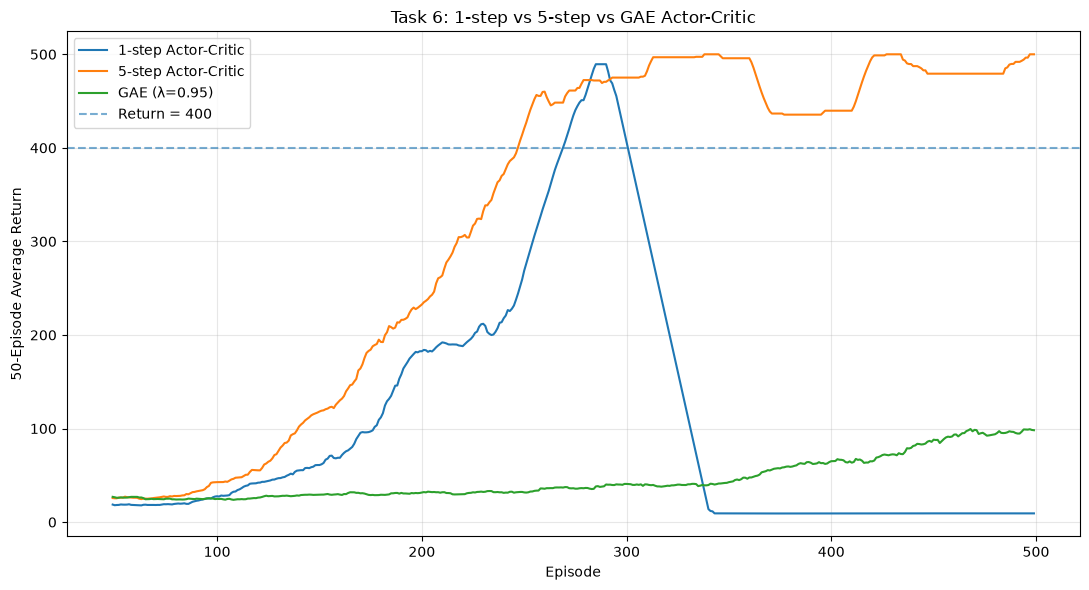

Saved figure: /workspace/YiFan/llm_agent/repos/RL-beginner/task-06-actor-critic/figures/task06_actor_critic_comparison.png


In [10]:

one_returns = np.asarray(
    one_step_results["episode_returns"],
    dtype=np.float32,
)

five_returns = np.asarray(
    five_step_results["episode_returns"],
    dtype=np.float32,
)

gae_returns = np.asarray(
    gae_results["episode_returns"],
    dtype=np.float32,
)

one_ma = moving_average(
    one_returns,
    window=MOVING_AVG_WINDOW,
)

five_ma = moving_average(
    five_returns,
    window=MOVING_AVG_WINDOW,
)

gae_ma = moving_average(
    gae_returns,
    window=MOVING_AVG_WINDOW,
)

plt.figure(figsize=(11, 6))

plt.plot(
    np.arange(
        MOVING_AVG_WINDOW - 1,
        len(one_returns),
    ),
    one_ma,
    label="1-step Actor-Critic",
)

plt.plot(
    np.arange(
        MOVING_AVG_WINDOW - 1,
        len(five_returns),
    ),
    five_ma,
    label="5-step Actor-Critic",
)

plt.plot(
    np.arange(
        MOVING_AVG_WINDOW - 1,
        len(gae_returns),
    ),
    gae_ma,
    label=f"GAE (λ={GAE_LAMBDA})",
)

plt.axhline(
    SUCCESS_THRESHOLD,
    linestyle="--",
    alpha=0.6,
    label=f"Return = {SUCCESS_THRESHOLD}",
)

plt.xlabel("Episode")
plt.ylabel(
    f"{MOVING_AVG_WINDOW}-Episode Average Return"
)

plt.title(
    "Task 6: 1-step vs 5-step vs GAE Actor-Critic"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

comparison_figure_path = (
    FIGURE_DIR
    / "task06_actor_critic_comparison.png"
)

plt.savefig(
    comparison_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:", comparison_figure_path)


## 7. 最终指标统计与结果保存

In [11]:

def summarize_experiment(
    name,
    returns,
):
    returns = np.asarray(
        returns,
        dtype=np.float32,
    )

    ma = moving_average(
        returns,
        window=MOVING_AVG_WINDOW,
    )

    return {
        "Algorithm": name,
        "Best 50-Episode Avg": (
            float(ma.max())
            if len(ma) > 0
            else np.nan
        ),
        "Final 100 Mean": float(
            returns[-100:].mean()
        ),
        "Final 100 Std": float(
            returns[-100:].std()
        ),
        "First Reach 400": first_reach_threshold(
            returns,
            threshold=SUCCESS_THRESHOLD,
            window=MOVING_AVG_WINDOW,
        ),
    }


summary = pd.DataFrame(
    [
        summarize_experiment(
            "1-step AC",
            one_returns,
        ),
        summarize_experiment(
            "5-step AC",
            five_returns,
        ),
        summarize_experiment(
            f"GAE λ={GAE_LAMBDA}",
            gae_returns,
        ),
    ]
)

display(summary)

summary_path = (
    RESULT_DIR
    / "task06_summary.csv"
)

summary.to_csv(
    summary_path,
    index=False,
)

npz_path = (
    RESULT_DIR
    / "task06_training_returns.npz"
)

np.savez(
    npz_path,
    one_step=one_returns,
    five_step=five_returns,
    gae=gae_returns,
)

print()
print("Saved summary:", summary_path)
print("Saved raw returns:", npz_path)


,Algorithm,Best 50-Episode Avg,Final 100 Mean,Final 100 Std,First Reach 400
0,1-step AC,489.400024,9.340000,0.710211,270.0
1,5-step AC,500.000000,489.640015,39.855118,248.0
2,GAE λ=0.95,99.500000,92.029999,57.503296,NaN



Saved summary: /workspace/YiFan/llm_agent/repos/RL-beginner/task-06-actor-critic/results/task06_summary.csv
Saved raw returns: /workspace/YiFan/llm_agent/repos/RL-beginner/task-06-actor-critic/results/task06_training_returns.npz



## 8. Checkpoint 输出

运行完成后，`checkpoints/` 中应包含：

```text
one_step_ac_best.pt
one_step_ac_final.pt

5_step_ac_best.pt
5_step_ac_final.pt

gae_ac_best.pt
gae_ac_final.pt
```

其中：

- `best.pt`：训练过程中 50-Episode Moving Average 最优时的模型；
- `final.pt`：最后一个 Episode 结束后的模型。

每个 checkpoint 保存：

- Actor 参数；
- Critic 参数；
- Actor optimizer；
- Critic optimizer；
- Episode；
- score；
- 实验配置。


In [12]:

checkpoint_files = sorted(
    CHECKPOINT_DIR.glob("*.pt")
)

for path in checkpoint_files:
    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    print(
        f"{path.name:28s} | "
        f"episode={checkpoint['episode']:4d} | "
        f"score={checkpoint['score']:.2f}"
    )


5_step_ac_best.pt            | episode= 339 | score=500.00
5_step_ac_final.pt           | episode= 500 | score=489.64
gae_ac_best.pt               | episode= 469 | score=99.50
gae_ac_final.pt              | episode= 500 | score=92.03
one_step_ac_best.pt          | episode= 286 | score=489.40
one_step_ac_final.pt         | episode= 500 | score=9.34
